03/03/2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Data points
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

print("X:\n", X)
print("Y:\n", Y)
print("A:\n", A)

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"\nSlope: {m}, Intercept: {c}")

X:
 [1 2 3 4 5]
Y:
 [1.2 2.8 3.6 4.5 5.1]
A:
 [[1. 1.]
 [2. 1.]
 [3. 1.]
 [4. 1.]
 [5. 1.]]

Slope: 0.9500000000000001, Intercept: 0.5900000000000001


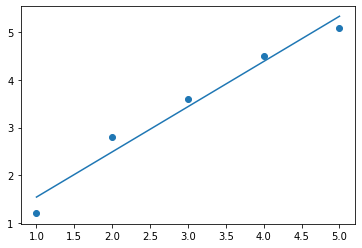

In [2]:
y = 0.95*X + 0.59

plt.scatter(X,Y)
plt.plot(X, y)
plt.show()

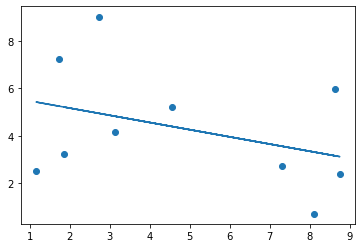

In [37]:
a = np.random.uniform(0, 10, 10)
b = np.random.uniform(0, 10, 10)

d = np.vstack([a, np.ones(len(a))]).T

m, c = np.linalg.lstsq(d, b, rcond=None)[0]

y1 = m*a + c

plt.scatter(a,b)
plt.plot(a, y1)
plt.show()

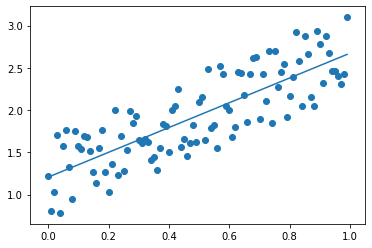

In [3]:
x = np.arange(0, 1, 0.01)
a = np.random.uniform(0, 1, len(x))

A = np.vstack([x, np.ones(len(x))]).T

y = (3/2)*x + 0.7 + a


m, c = np.linalg.lstsq(A, y, rcond=None)[0]

y1 = m*x + c

plt.scatter(x, y)
plt.plot(x, y1)
plt.show()

In [8]:
# Challenge A

In [4]:
# Mean Squared Error (MSE)
mse_leastsquares = np.mean((y - y1)**2)
print(f'Mean Squared Error: {mse_leastsquares:.4f}')

# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y1)**2)
r_squared_leastsquares = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared_leastsquares:.4f}')

Mean Squared Error: 0.0885
R-squared: 0.6699


Polynomial Coefficients:  [-1.06533539  1.80092338  0.62769593  1.29126386]


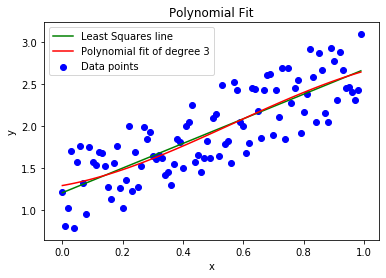

In [5]:
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x)

# Plotting the results
plt.plot(x, y1, 'g', label='Least Squares line')
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [6]:
# Mean Squared Error (MSE)
mse_cubic = np.mean((y - y_pred)**2)
print(f'Mean Squared Error: {mse_cubic:.4f}')

# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_squared_cubic = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared_cubic:.4f}')

Mean Squared Error: 0.0878
R-squared: 0.6724


In [7]:
if ((mse_leastsquares<mse_cubic) & (r_squared_leastsquares>r_squared_cubic)):
    print("Lower MSE =", mse_leastsquares, "\nHigher R-Squared Value =", r_squared_leastsquares)
    print("The Linear Least Squares method is a better fit because the MSE is closer to 0 and the R-Squared value is closer to 1 compared to the Polynomial fit.")
else:
    print("Lower MSE =", mse_cubic, "\nHigher R-Squared Value =", r_squared_cubic)
    print("The Polynomial fit method (cubic) is a better fit because the MSE is closer to 0 and the R-Squared value is closer to 1 compared to the Linear fit.")

Lower MSE = 0.08779334108133527 
Higher R-Squared Value = 0.6723754214937401
The Polynomial fit method (cubic) is a better fit because the MSE is closer to 0 and the R-Squared value is closer to 1 compared to the Linear fit.


In [9]:
# Challenge B

In [ ]:
degree = 3
while ((mse > 0) & (r_squared < 1)):
    degree += 1 # Degree of the polynomial
    coefficients = np.polyfit(x, y, degree)

    # Use the coefficients to predict y-values (polynomial function)
    # Generate polynomial function based on the coefficients
    polynomial = np.poly1d(coefficients)

    # Generate predicted y-values based on the fitted polynomial
    y_pred = polynomial(x)

    # Mean Squared Error (MSE)
    mse = np.mean((y - y_pred)**2)

    # R-squared value
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    
print(degree)    
print("Polynomial Coefficients: ", coefficients)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')

# Plotting the results
plt.plot(x, y1, 'g', label='Least Squares line')
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()